In [5]:
#2. EDA

In [67]:
#2.1 Trying to add important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
#2.2 Loading and reading he dataset
df = pd.read_csv(r"C:\Users\priya\Desktop\global_startup_success_dataset.csv")

In [69]:
#2.3 printing the frist 10 rows of the dataset to confirm that the datset is loaded
print(df.head(10))
print(df.info())

  Startup Name  Founded Year    Country    Industry Funding Stage  \
0    Startup_1          2009     Canada  Healthcare      Series A   
1    Startup_2          2004         UK  Healthcare           IPO   
2    Startup_3          2018        USA  Healthcare          Seed   
3    Startup_4          2014     France        Tech          Seed   
4    Startup_5          2006      Japan      Energy      Series C   
5    Startup_6          2017         UK     FinTech      Series B   
6    Startup_7          2014      China      Gaming      Series C   
7    Startup_8          2018  Australia      EdTech      Series B   
8    Startup_9          2006     Canada          AI      Series B   
9   Startup_10          2004        USA  E-commerce      Series A   

   Total Funding ($M)  Number of Employees  Annual Revenue ($M)  \
0                 269                 3047                  104   
1                  40                  630                  431   
2                 399                 2

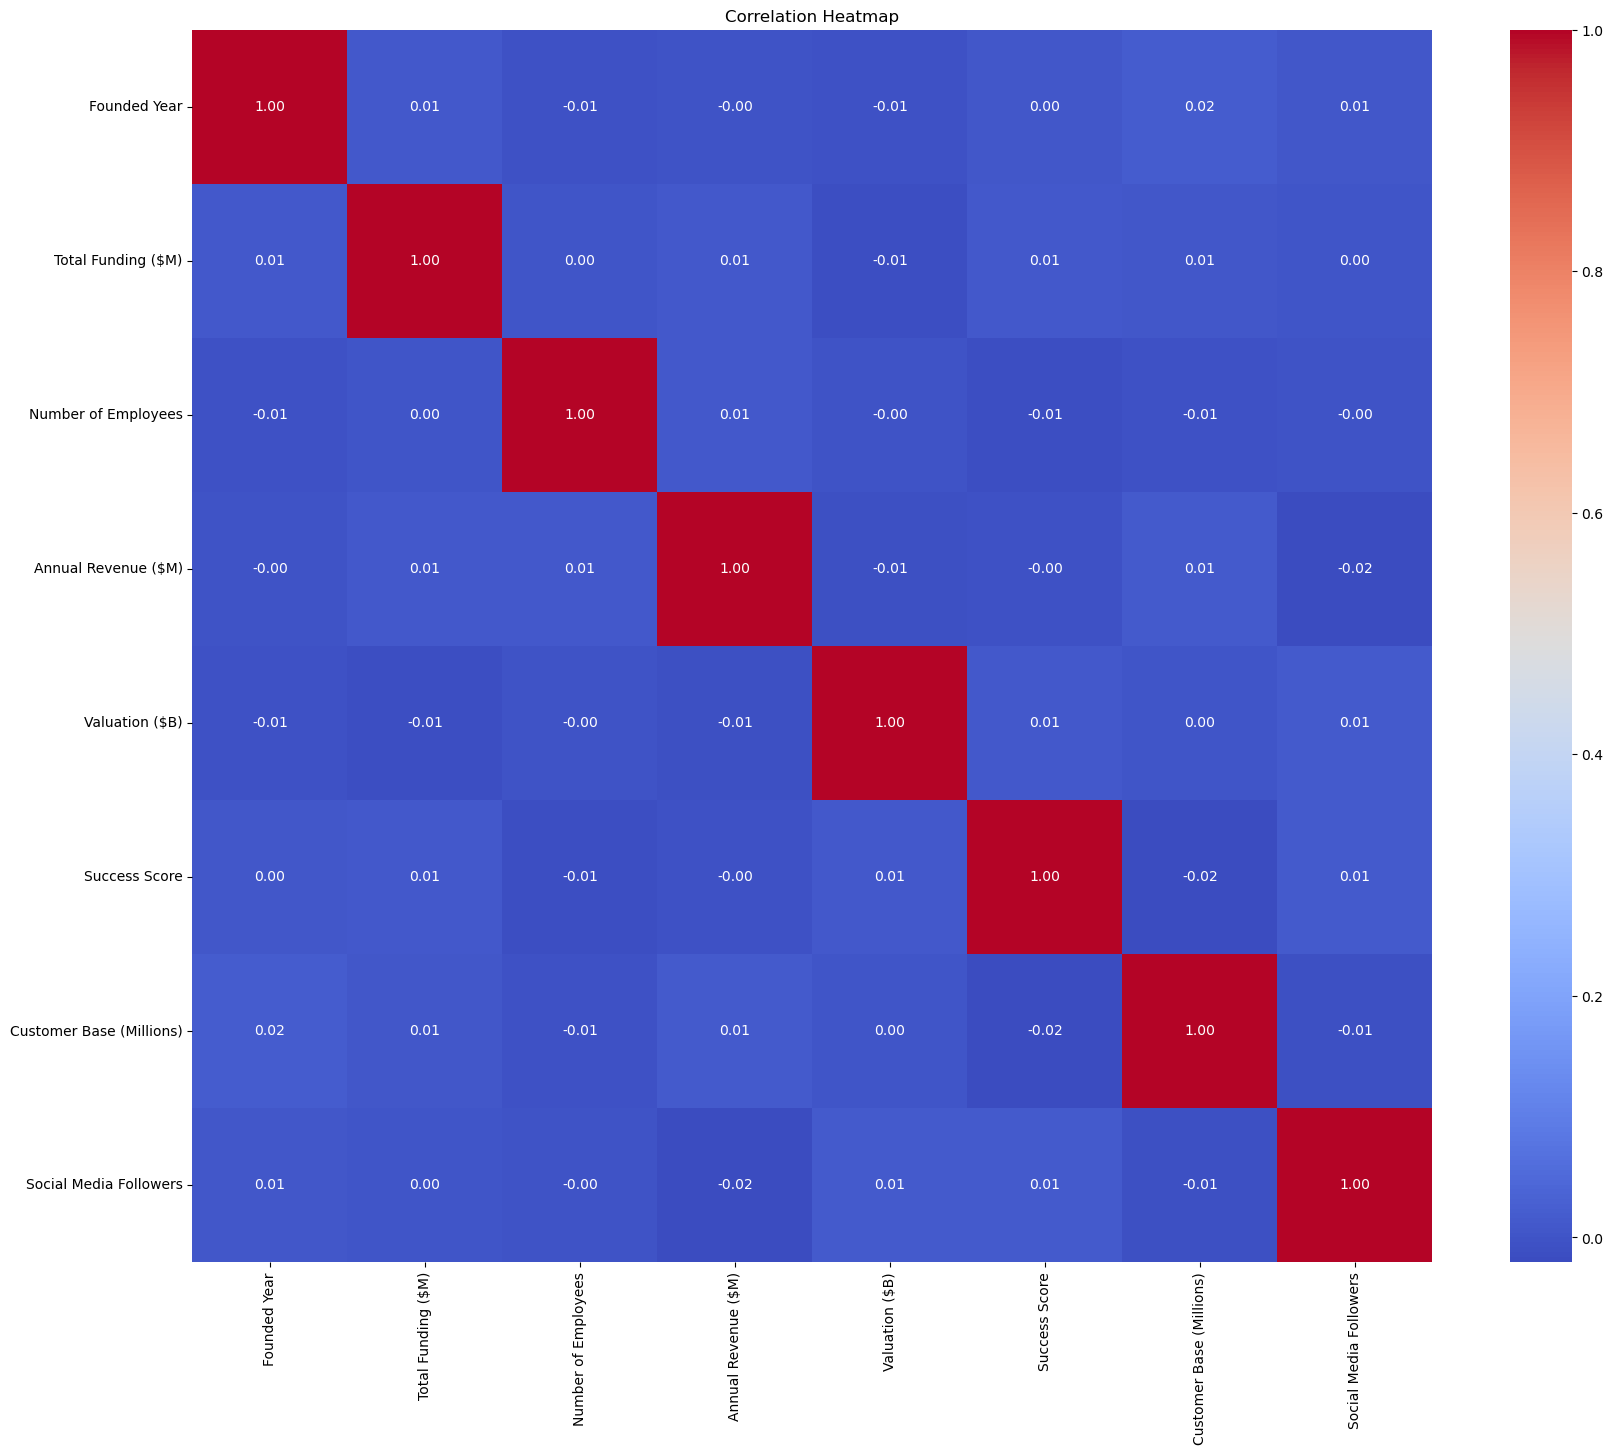

In [70]:
#2.4 Correlation heat map of the whole dataset
df_numeric = df.select_dtypes(include=['number'])
corr = df_numeric.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')

<Axes: xlabel='Country', ylabel='count'>

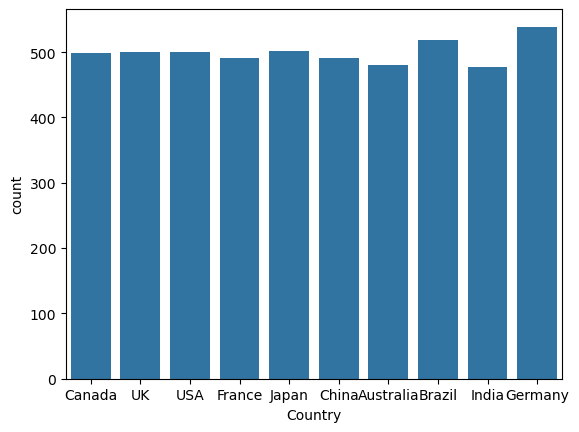

In [71]:
#2.5 Graph based on countires having number of startups
sns.countplot(x='Country', data=df)

<Axes: xlabel='Industry', ylabel='count'>

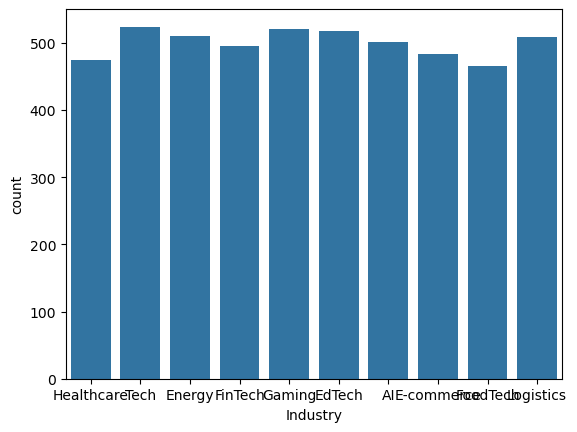

In [72]:
#2.6 Graph based on Industry having number of startups
sns.countplot(x='Industry', data=df)

In [73]:
#2.7 Count of startups in each Country
df['Country'].value_counts()

Country
Germany      539
Brazil       519
Japan        502
UK           501
USA          501
Canada       498
China        491
France       491
Australia    480
India        478
Name: count, dtype: int64

In [74]:
#2.8 Count of startups in each funding stage
df['Funding Stage'].value_counts()

Funding Stage
IPO         1037
Seed        1008
Series A    1003
Series B     983
Series C     969
Name: count, dtype: int64

In [75]:
#2.9 Count of startups in each Industry
df['Industry'].value_counts()

Industry
Tech          524
Gaming        520
EdTech        518
Energy        510
Logistics     509
AI            501
FinTech       496
E-commerce    483
Healthcare    474
FoodTech      465
Name: count, dtype: int64

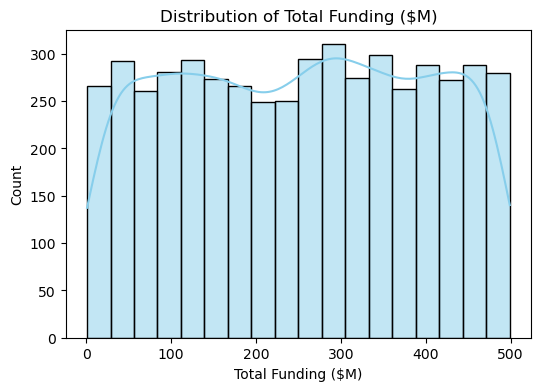

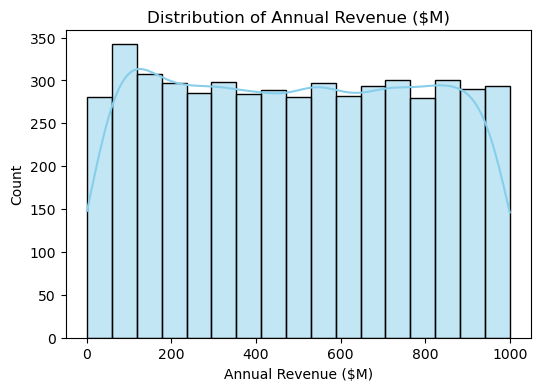

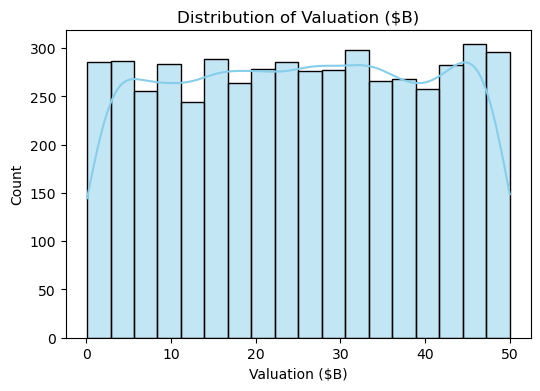

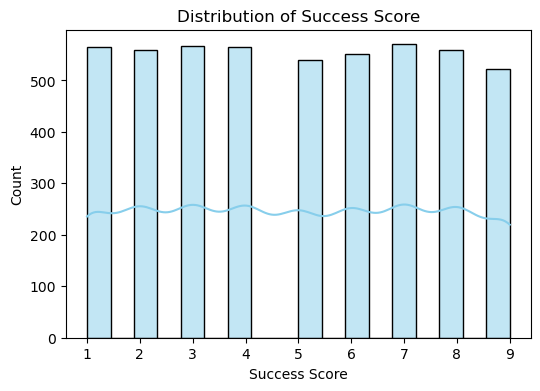

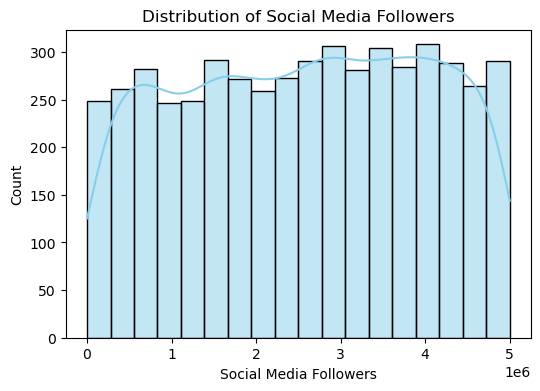

In [76]:
#2.10 Distribution in each important features to find outliers
numeric_cols = ['Total Funding ($M)', 'Annual Revenue ($M)', 'Valuation ($B)', 'Success Score', 'Social Media Followers']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

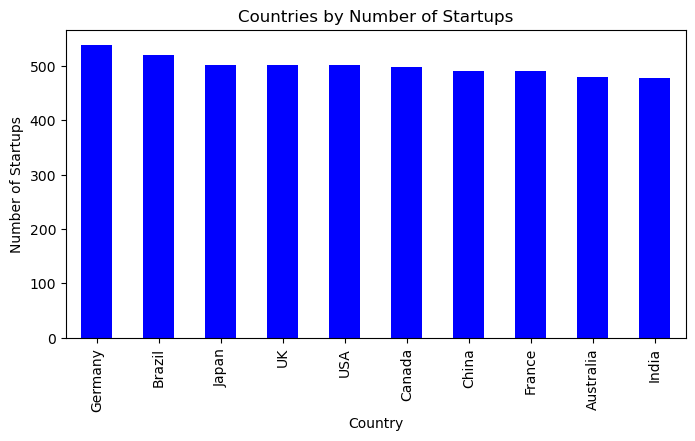

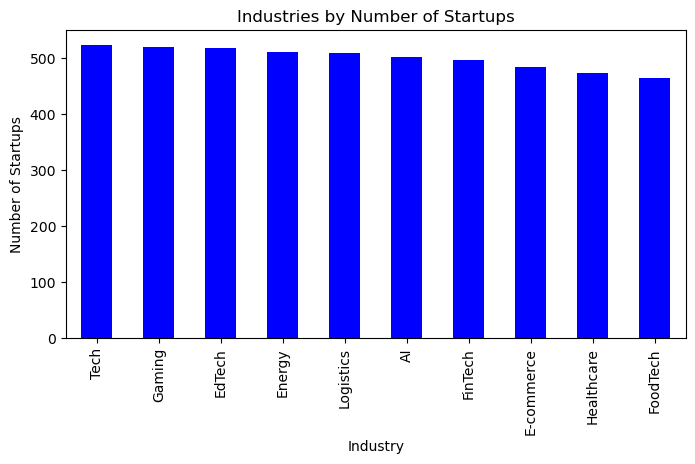

In [77]:
#2.11 Visual representation of Startups based on Countries and Industry
plt.figure(figsize=(8,4))
df['Country'].value_counts().head(10).plot(kind='bar', color='blue')
plt.title("Countries by Number of Startups")
plt.ylabel("Number of Startups")
plt.show()

plt.figure(figsize=(8,4))
df['Industry'].value_counts().head(10).plot(kind='bar', color='blue')
plt.title("Industries by Number of Startups")
plt.ylabel("Number of Startups")
plt.show()

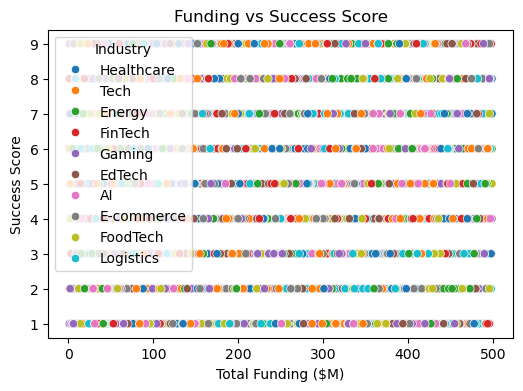

In [78]:
#2.12 Scatter Plot based on how funding amounts relate to success scores, and how this pattern varies across industries.
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Total Funding ($M)', y='Success Score', hue='Industry')
plt.title("Funding vs Success Score")
plt.xlabel("Total Funding ($M)")
plt.ylabel("Success Score")
plt.show()

C:\Users\priya\AppData\Local\Temp\ipykernel_16340\3346480311.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Industry", y="Total Funding ($M)", data=df, palette="pastel")


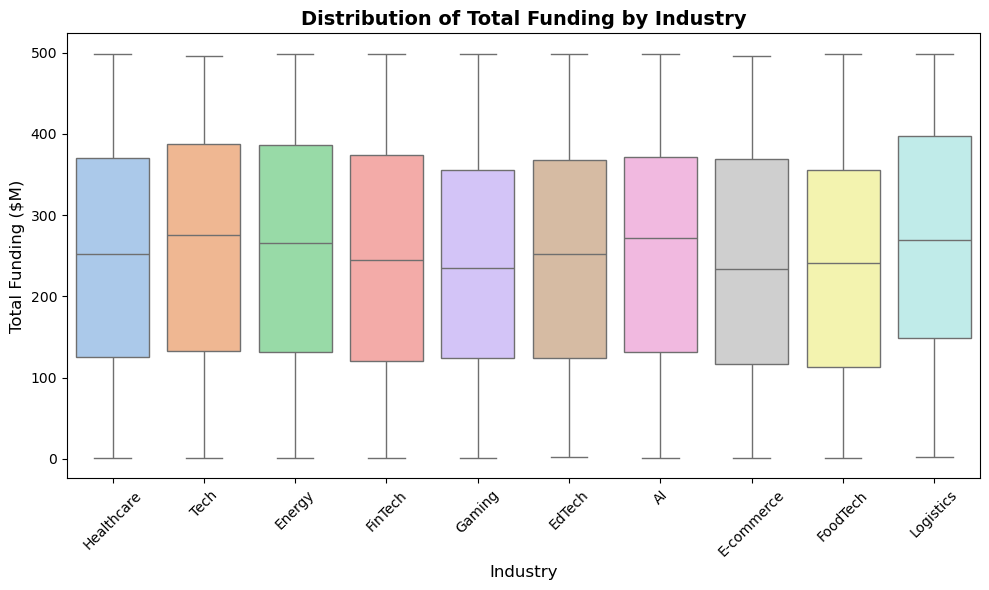

In [79]:
#2.13 Box Plot based on comparing funding distributions across industries.
# X-axis: Industry categories
# Y-axis: Total Funding (in $M)
# Each box: Funding distribution within that industry
plt.figure(figsize=(10,6))
sns.boxplot(x="Industry", y="Total Funding ($M)", data=df, palette="pastel")


plt.title("Distribution of Total Funding by Industry", fontsize=14, weight='bold')
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Total Funding ($M)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

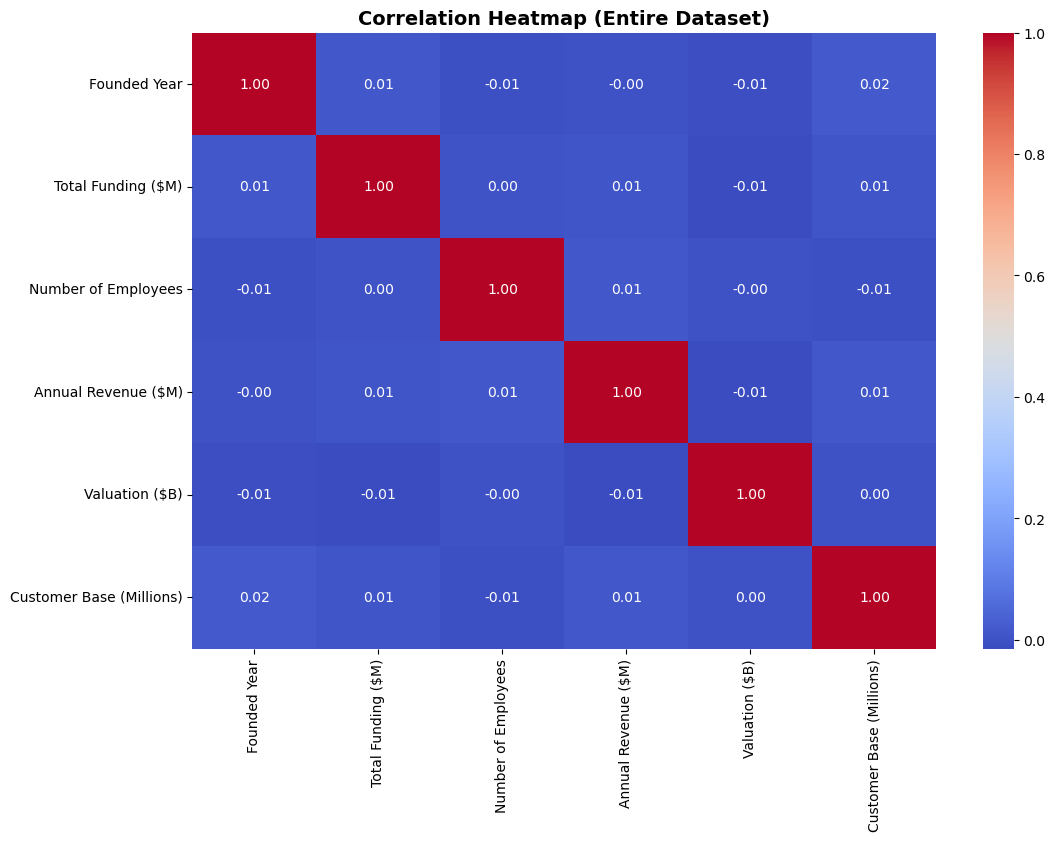

In [80]:
#2.14 Correlation based on the important features in the dataset
to_drop = ["Startup Name", "Success Score", "Funding Stage", "Acquired?", "IPO?", "Social Media Followers"]
df_cleaned = df.drop(columns=to_drop, errors="ignore")

plt.figure(figsize=(12,8))
numeric_df = df_cleaned.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Entire Dataset)", fontsize=14, weight='bold')
plt.show()

In [81]:
to_drop = ["Startup Name", "Success Score", "Funding Stage", "Acquired?", "IPO?", "Social Media Followers"]
df_cleaned = df.drop(columns=to_drop, errors="ignore")

In [82]:
df_no_industry = df_cleaned.drop(columns=["Industry"], errors="ignore")

df_cleaned.head()

,Founded Year,Country,Industry,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Tech Stack
0,2009,Canada,Healthcare,269,3047,104,46.11,43,"Java, Spring"
1,2004,UK,Healthcare,40,630,431,33.04,64,"Node.js, React"
2,2018,USA,Healthcare,399,2475,375,15.79,74,"PHP, Laravel"
3,2014,France,Tech,404,1011,907,17.12,26,"Python, AI"
4,2006,Japan,Energy,419,3917,280,4.39,30,"Node.js, React"


In [83]:
if "Total Funding ($M)" in df_cleaned.columns and "Annual Revenue ($M)" in df_cleaned.columns:
    df_cleaned["Profitability Ratio"] = np.where(
        df_cleaned["Total Funding ($M)"] > 0,
        df_cleaned["Annual Revenue ($M)"] / df_cleaned["Total Funding ($M)"],
        np.nan
    )

    df_cleaned["Profitability Ratio"] = df_cleaned["Profitability Ratio"].clip(upper=100)

df_cleaned.head()

,Founded Year,Country,Industry,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Tech Stack,Profitability Ratio
0,2009,Canada,Healthcare,269,3047,104,46.11,43,"Java, Spring",0.386617
1,2004,UK,Healthcare,40,630,431,33.04,64,"Node.js, React",10.775000
2,2018,USA,Healthcare,399,2475,375,15.79,74,"PHP, Laravel",0.939850
3,2014,France,Tech,404,1011,907,17.12,26,"Python, AI",2.245050
4,2006,Japan,Energy,419,3917,280,4.39,30,"Node.js, React",0.668258


In [84]:
columns_to_drop = ["Industry", "Acquired?", "IPO?"]  # drop these in each subset

saved = []
for industry in sorted(df_cleaned["Industry"].dropna().unique()):
    subset = df_cleaned[df_cleaned["Industry"] == industry].copy()
    subset = subset.drop(columns=columns_to_drop, errors="ignore")
    fname = f"{industry.replace(' ', '_')}_startups.csv"
    subset.to_csv(fname, index=False)
    saved.append((fname, subset.shape[0]))

print("Per-industry CSVs:")
for name, rows in saved:
    print(f"{name} — {rows} rows")

Per-industry CSVs:
AI_startups.csv — 501 rows
E-commerce_startups.csv — 483 rows
EdTech_startups.csv — 518 rows
Energy_startups.csv — 510 rows
FinTech_startups.csv — 496 rows
FoodTech_startups.csv — 465 rows
Gaming_startups.csv — 520 rows
Healthcare_startups.csv — 474 rows
Logistics_startups.csv — 509 rows
Tech_startups.csv — 524 rows


In [85]:
summary_by_industry = (
    df_cleaned.groupby("Industry")
      .agg(
          startups=("Country", "count"),
          avg_funding_m=("Total Funding ($M)", "mean"),
          avg_revenue_m=("Annual Revenue ($M)", "mean"),
          avg_valuation_b=("Valuation ($B)", "mean"),
          avg_profit_ratio=("Profitability Ratio", "mean")
      )
      .sort_values(by="avg_profit_ratio", ascending=False)
      .round(2)
)
summary_by_industry

,startups,avg_funding_m,avg_revenue_m,avg_valuation_b,avg_profit_ratio
Industry,,,,,
AI,501,257.42,503.05,24.59,6.07
FoodTech,465,240.37,524.26,25.53,6.04
Healthcare,474,247.95,511.32,25.85,5.52
Gaming,520,242.13,483.90,24.84,5.40
FinTech,496,249.50,494.82,25.73,5.27
Energy,510,258.69,473.55,26.04,5.18
EdTech,518,247.54,479.15,24.79,5.18
E-commerce,483,241.99,485.27,24.72,4.84
Tech,524,259.51,500.73,25.44,4.73


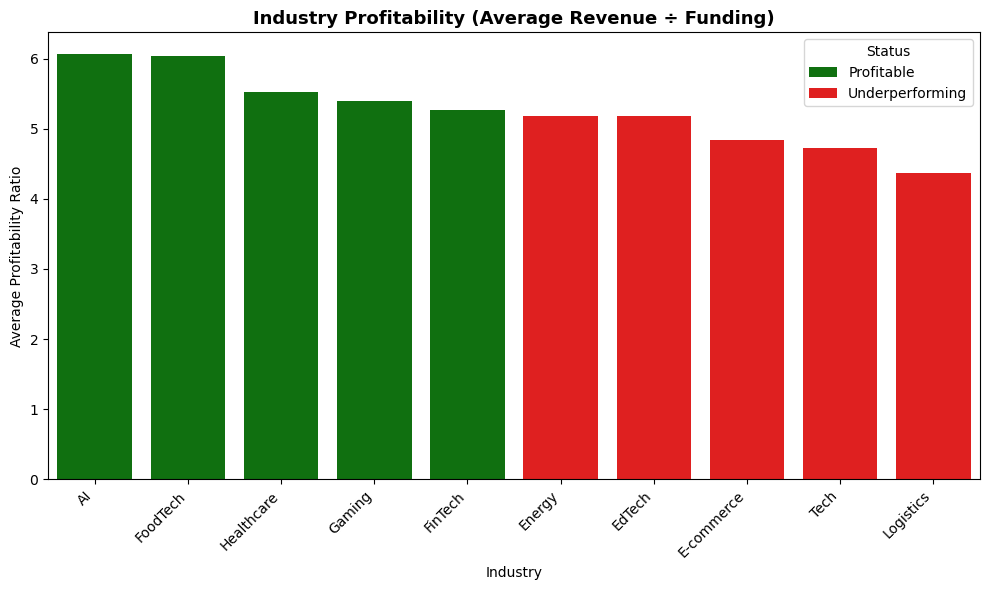

In [86]:
#2.15 Label relative to overall mean profitability
overall_avg = df_cleaned["Profitability Ratio"].mean()
profit_status = (summary_by_industry["avg_profit_ratio"]
                 .apply(lambda x: "Profitable" if x > overall_avg else "Underperforming"))

plot_df = summary_by_industry.assign(Status=profit_status).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x="Industry", y="avg_profit_ratio",
            hue="Status", dodge=False,
            palette={"Profitable": "green", "Underperforming": "red"})
plt.title("Industry Profitability (Average Revenue ÷ Funding)", fontsize=13, weight="bold")
plt.xlabel("Industry")
plt.ylabel("Average Profitability Ratio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("profitability.png", dpi=300, bbox_inches='tight')
plt.show()



In [87]:
df["Profitability Ratio"] = np.where(
    df["Total Funding ($M)"] > 0,
    df["Annual Revenue ($M)"] / df["Total Funding ($M)"],
    np.nan
)

In [88]:
#2.16 Co relation table created to understand the relation between the features without industry coloumn
def compare_industry_correlation(df_cleaned, industry_name):
    """
    Compares numeric feature correlations between a specific industry subset
    and the full dataset (df_cleaned).
    """
    industry_df = df_cleaned[df_cleaned["Industry"] == industry_name]
    num_cols = df_cleaned.select_dtypes(include=["number"]).columns
    main_corr = df_cleaned[num_cols].corr()
    industry_corr = industry_df[num_cols].corr()
    diff_corr = (industry_corr - main_corr).round(2)
    print(f"\n Correlation Difference for Industry: {industry_name}")
    return diff_corr

In [89]:
industry_names = df_cleaned["Industry"].dropna().unique()

industry_corr_diffs = {}
for ind in industry_names:
    diff = compare_industry_correlation(df_cleaned, ind)
    industry_corr_diffs[ind] = diff


 Correlation Difference for Industry: Healthcare

 Correlation Difference for Industry: Tech

 Correlation Difference for Industry: Energy

 Correlation Difference for Industry: FinTech

 Correlation Difference for Industry: Gaming

 Correlation Difference for Industry: EdTech

 Correlation Difference for Industry: AI

 Correlation Difference for Industry: E-commerce

 Correlation Difference for Industry: FoodTech

 Correlation Difference for Industry: Logistics


In [90]:
# Correlation table for Healthcare
industry_corr_diffs["Healthcare"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,0.04,-0.07,-0.01,0.05,0.07,0.00
Total Funding ($M),0.04,0.00,-0.01,-0.03,0.04,0.06,-0.01
Number of Employees,-0.07,-0.01,0.00,-0.04,0.00,0.03,0.03
Annual Revenue ($M),-0.01,-0.03,-0.04,0.00,-0.08,-0.02,0.07
Valuation ($B),0.05,0.04,0.00,-0.08,0.00,0.01,0.00
Customer Base (Millions),0.07,0.06,0.03,-0.02,0.01,0.00,-0.05
Profitability Ratio,0.00,-0.01,0.03,0.07,0.00,-0.05,0.00


In [30]:
# Correlation table for Energy
industry_corr_diffs["Energy"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,0.06,0.03,-0.00,-0.01,-0.05,-0.04
Total Funding ($M),0.06,0.00,-0.02,0.04,-0.02,-0.03,0.00
Number of Employees,0.03,-0.02,0.00,-0.03,-0.06,-0.00,0.01
Annual Revenue ($M),-0.00,0.04,-0.03,0.00,-0.02,-0.05,-0.02
Valuation ($B),-0.01,-0.02,-0.06,-0.02,0.00,0.01,0.04
Customer Base (Millions),-0.05,-0.03,-0.00,-0.05,0.01,0.00,0.06
Profitability Ratio,-0.04,0.00,0.01,-0.02,0.04,0.06,0.00


In [31]:
# Correlation table for FinTech
industry_corr_diffs["FinTech"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,-0.03,-0.02,0.01,0.05,0.04,-0.06
Total Funding ($M),-0.03,0.00,0.00,-0.04,-0.04,-0.03,0.02
Number of Employees,-0.02,0.00,0.00,0.03,-0.03,-0.05,0.02
Annual Revenue ($M),0.01,-0.04,0.03,0.00,0.05,-0.04,-0.00
Valuation ($B),0.05,-0.04,-0.03,0.05,0.00,0.02,0.03
Customer Base (Millions),0.04,-0.03,-0.05,-0.04,0.02,0.00,0.08
Profitability Ratio,-0.06,0.02,0.02,-0.00,0.03,0.08,0.00


In [32]:
# Correlation table for Gaming
industry_corr_diffs["Gaming"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,-0.12,-0.02,-0.02,-0.03,-0.05,0.07
Total Funding ($M),-0.12,0.00,0.02,-0.01,0.02,0.05,0.01
Number of Employees,-0.02,0.02,0.00,0.00,-0.01,-0.05,-0.02
Annual Revenue ($M),-0.02,-0.01,0.00,0.00,0.00,0.04,0.02
Valuation ($B),-0.03,0.02,-0.01,0.00,0.00,-0.02,0.01
Customer Base (Millions),-0.05,0.05,-0.05,0.04,-0.02,0.00,-0.06
Profitability Ratio,0.07,0.01,-0.02,0.02,0.01,-0.06,0.00


In [33]:
# Correlation table for EdTech
industry_corr_diffs["EdTech"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,0.03,-0.02,0.05,0.00,-0.02,0.01
Total Funding ($M),0.03,0.00,0.07,-0.00,0.01,0.07,-0.02
Number of Employees,-0.02,0.07,0.00,0.04,0.01,0.02,-0.01
Annual Revenue ($M),0.05,-0.00,0.04,0.00,0.09,-0.01,0.05
Valuation ($B),0.00,0.01,0.01,0.09,0.00,0.05,0.04
Customer Base (Millions),-0.02,0.07,0.02,-0.01,0.05,0.00,-0.00
Profitability Ratio,0.01,-0.02,-0.01,0.05,0.04,-0.00,0.00


In [34]:
# Correlation table for AI
industry_corr_diffs["AI"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,0.02,-0.02,-0.03,0.04,0.04,-0.04
Total Funding ($M),0.02,0.00,-0.01,-0.06,0.04,-0.03,-0.03
Number of Employees,-0.02,-0.01,0.00,-0.06,-0.05,0.07,0.04
Annual Revenue ($M),-0.03,-0.06,-0.06,0.00,0.07,0.01,-0.02
Valuation ($B),0.04,0.04,-0.05,0.07,0.00,-0.10,-0.03
Customer Base (Millions),0.04,-0.03,0.07,0.01,-0.10,0.00,0.03
Profitability Ratio,-0.04,-0.03,0.04,-0.02,-0.03,0.03,0.00


In [35]:
# Correlation table for E-commerce
industry_corr_diffs["E-commerce"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,0.06,0.01,0.08,-0.00,0.01,-0.01
Total Funding ($M),0.06,0.00,0.02,-0.02,-0.07,-0.05,-0.03
Number of Employees,0.01,0.02,0.00,0.04,0.02,0.05,0.04
Annual Revenue ($M),0.08,-0.02,0.04,0.00,-0.06,0.02,0.07
Valuation ($B),-0.00,-0.07,0.02,-0.06,0.00,-0.07,0.00
Customer Base (Millions),0.01,-0.05,0.05,0.02,-0.07,0.00,0.13
Profitability Ratio,-0.01,-0.03,0.04,0.07,0.00,0.13,0.00


In [36]:
# Correlation table for FoodTech
industry_corr_diffs["FoodTech"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,0.01,0.05,-0.06,-0.10,0.01,0.02
Total Funding ($M),0.01,0.00,-0.09,0.06,0.01,-0.03,0.00
Number of Employees,0.05,-0.09,0.00,-0.01,0.12,-0.01,-0.01
Annual Revenue ($M),-0.06,0.06,-0.01,0.00,-0.06,-0.03,-0.06
Valuation ($B),-0.10,0.01,0.12,-0.06,0.00,-0.00,-0.02
Customer Base (Millions),0.01,-0.03,-0.01,-0.03,-0.00,0.00,-0.02
Profitability Ratio,0.02,0.00,-0.01,-0.06,-0.02,-0.02,0.00


In [37]:
# Correlation table for Logistics
industry_corr_diffs["Logistics"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,-0.03,0.08,-0.03,-0.03,-0.05,0.02
Total Funding ($M),-0.03,0.00,0.05,0.06,-0.05,0.01,0.03
Number of Employees,0.08,0.05,0.00,0.03,-0.03,-0.08,-0.09
Annual Revenue ($M),-0.03,0.06,0.03,0.00,0.03,0.02,-0.03
Valuation ($B),-0.03,-0.05,-0.03,0.03,0.00,0.08,-0.03
Customer Base (Millions),-0.05,0.01,-0.08,0.02,0.08,0.00,-0.09
Profitability Ratio,0.02,0.03,-0.09,-0.03,-0.03,-0.09,0.00


In [38]:
# Correlation table for Tech
industry_corr_diffs["Tech"]

,Founded Year,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Customer Base (Millions),Profitability Ratio
Founded Year,0.00,-0.02,-0.01,0.02,0.01,-0.01,0.05
Total Funding ($M),-0.02,0.00,-0.03,0.01,0.05,-0.02,-0.00
Number of Employees,-0.01,-0.03,0.00,0.00,0.02,0.04,-0.04
Annual Revenue ($M),0.02,0.01,0.00,0.00,-0.03,0.03,-0.05
Valuation ($B),0.01,0.05,0.02,-0.03,0.00,0.02,-0.05
Customer Base (Millions),-0.01,-0.02,0.04,0.03,0.02,0.00,-0.07
Profitability Ratio,0.05,-0.00,-0.04,-0.05,-0.05,-0.07,0.00


In [39]:
#3. Initial data Preparation

In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
#3.1 Load dataset
#df = pd.read_csv(r"C:\Users\ROG\Desktop\global_startup_success_dataset.csv")

#3.2 Make dummy variables for Industry, but DO NOT remove original column
industry_dummies = pd.get_dummies(df["Industry"], prefix="Industry", dtype=int)

#3.3 Add dummy columns to the dataframe
df_with_dummies = pd.concat([df, industry_dummies], axis=1)

#3.4  Columns you want to drop (Industry will be kept)
to_drop = ["Startup Name", "Success Score", "Funding Stage", "Acquired?", "IPO?", "Tech Stack", "Social Media Followers"]

df_cleaned = df_with_dummies.drop(columns=to_drop, errors="ignore")

#3.5 Save the final dataset
df_cleaned.to_csv("global_startup_success_initial_dataset5.csv", index=False)


In [92]:
df = pd.read_csv(r"global_startup_success_initial_dataset5.csv")

In [93]:
#3.6 Calculate startup age (current year - founded year)
df['Age'] = 2025 - df['Founded Year']

In [94]:
#3.7 Normalize Age within each industry
# This divides each startup’s Age by the mean age of startups in the same industry
df['Age_IndustryNorm'] = df['Age'] / df.groupby('Industry')['Age'].transform('mean')

In [95]:
#3.8 Normalize valuation within each industry and also the annual revenue, customerbase and total funding in each industry
df['Valuation ($B)_IndustryNorm'] = df['Valuation ($B)'] / df.groupby('Industry')['Valuation ($B)'].transform('mean')
df['Annual Revenue ($M)_IndustryNorm'] = df['Annual Revenue ($M)'] / df.groupby('Industry')['Annual Revenue ($M)'].transform('mean')
df['Customer Base (Millions)_IndustryNorm'] = df['Customer Base (Millions)'] / df.groupby('Industry')['Customer Base (Millions)'].transform('mean')
df['Total Funding ($M)_IndustryNorm'] = df['Total Funding ($M)'] / df.groupby('Industry')['Total Funding ($M)'].transform('mean')


In [96]:
#3.9 Define weights for each feature used to compute the composite success score
weights = {
    'Valuation ($B)': 0.25,
    'Total Funding ($M)': 0.25,
    'Customer Base (Millions)': 0.2,
    'Annual Revenue ($M)': 0.2,
    'Age': 0.1
}

df['Composite_Score'] = (
    df['Valuation ($B)_IndustryNorm']        * weights['Valuation ($B)'] +
    df['Customer Base (Millions)_IndustryNorm'] * weights['Customer Base (Millions)'] +
    df['Annual Revenue ($M)_IndustryNorm']   * weights['Annual Revenue ($M)'] +
    df['Total Funding ($M)_IndustryNorm']    * weights['Total Funding ($M)'] +
    df['Age_IndustryNorm']                   * weights['Age']
)


In [97]:
#3.10 Compute the composite score by taking a weighted sum of all normalized features.
# This gives each startup an overall performance score relative to its industry.
df['Success_Flag'] = (
    df['Composite_Score'] >= df.groupby('Industry')['Composite_Score'].transform(lambda x: x.quantile(0.75))
).astype(int)

In [98]:
df.to_csv('startups_with_success_flag5.csv')

In [48]:
# 4. Iterative Process

4.1 Logistic Regression

In [99]:
#4.1.1 Import Required Libraries
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [101]:
df = pd.read_csv(r"startups_with_success_flag5.csv")

In [102]:
#4.1.2 Select Feature Columns (X) and Target (y)
X = df[['Valuation ($B)',
        'Annual Revenue ($M)',
        'Total Funding ($M)',
        'Customer Base (Millions)',
        'Age']]

y = df['Success_Flag']

In [103]:
#4.1.3 Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [104]:
#4.1.4 Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
#4.1.5 LOGISTIC REGRESSION MODEL
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

In [106]:
#4.1.6 Logistic Regression Evaluation
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]))

from sklearn.metrics import classification_report, confusion_matrix
y_pred = log_model.predict(X_test_scaled)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Results
Accuracy: 0.969
ROC-AUC: 0.9972659429039517

Confusion Matrix:
 [[722  27]
 [  4 247]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98       749
           1       0.90      0.98      0.94       251

    accuracy                           0.97      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.97      0.97      0.97      1000



In [107]:
#4.1.7 Training accuracy (checking for overfitting)
from sklearn.metrics import accuracy_score

train_preds = log_model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_preds)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9745


In [108]:
#4.1.8 Cross-Validation (10-fold)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_model, X_train_scaled, y_train, cv=10, scoring='accuracy')

print("Cross Validation Accuracies:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())

Cross Validation Accuracies: [0.985  0.9725 0.9825 0.98   0.9725 0.9575 0.9775 0.96   0.975  0.9725]
Mean CV Accuracy: 0.9734999999999999
Std Deviation: 0.008455767262643885


In [109]:
#4.1.9 Logistic Regression Feature Importance
coefficients = log_model.coef_[0]  # For binary classification
feature_names = X.columns

# Combine into a DataFrame for easy viewing
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value (importance)
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print(coef_df[['Feature', 'Coefficient']])

                    Feature  Coefficient
2        Total Funding ($M)     6.540495
0            Valuation ($B)     6.365224
1       Annual Revenue ($M)     5.449374
3  Customer Base (Millions)     5.021224
4                       Age     2.193038


4.2 DECISION TREE MODEL

In [111]:
#4.2.1 Creating a Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    criterion='gini',       # or 'entropy'
    max_depth=None,         # can tune to avoid overfitting
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

# Predict
y_pred = dt_model.predict(X_test_scaled)

#4.2.2 Decision Tree Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC score
auc_dt = roc_auc_score(y_test, y_proba_dt)
print("Decision Tree ROC-AUC Score:", auc_dt)

Accuracy: 0.916

Confusion Matrix:
 [[712  37]
 [ 47 204]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       749
           1       0.85      0.81      0.83       251

    accuracy                           0.92      1000
   macro avg       0.89      0.88      0.89      1000
weighted avg       0.92      0.92      0.92      1000

Decision Tree ROC-AUC Score: 0.8816749025260774


In [112]:
#4.2.3 Decision Tree Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=10, scoring='accuracy')

print("Cross Validation Accuracies:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())

Cross Validation Accuracies: [0.92   0.8875 0.9    0.895  0.92   0.93   0.92   0.9025 0.915  0.8975]
Mean CV Accuracy: 0.9087500000000002
Std Deviation: 0.013240562676865388


4.3 KNN (K-Nearest Neighbors) model + tuning

In [113]:
#4.3.1 Import KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors

# Fit the model
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]
auc_knn = roc_auc_score(y_test, y_proba_knn)
print("KNN ROC-AUC Score:", auc_knn)

Accuracy: 0.942

Confusion Matrix:
 [[726  23]
 [ 35 216]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       749
           1       0.90      0.86      0.88       251

    accuracy                           0.94      1000
   macro avg       0.93      0.91      0.92      1000
weighted avg       0.94      0.94      0.94      1000

KNN ROC-AUC Score: 0.9845743860339683


In [114]:
#4.3.2  Perform 10-fold Cross-Validation
cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=10, scoring='accuracy')
print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("CV standard deviation:", np.std(cv_scores))

Cross-validation accuracies: [0.9475 0.95   0.945  0.945  0.935  0.9625 0.94   0.95   0.95   0.955 ]
Mean CV accuracy: 0.9479999999999998
CV standard deviation: 0.007228416147400478


Best k: 19
Best CV Accuracy: 0.9547500000000001


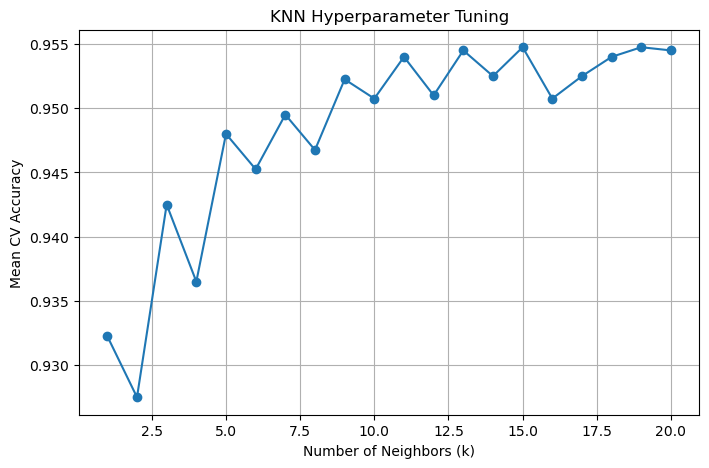

In [115]:
#4.3.3 Try values of k from 1 to 20
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find the k with the highest mean CV accuracy
best_k = k_values[np.argmax(cv_scores)]
print("Best k:", best_k)
print("Best CV Accuracy:", max(cv_scores))

# Plot k vs CV accuracy
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN Hyperparameter Tuning')
plt.grid(True)
plt.show()

4.4 Naive Bayes

In [116]:
#4.4.1 Creating a Naive Bayes Model
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Initialize and Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = nb_model.predict(X_test_scaled)

# Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
auc_nb = roc_auc_score(y_test, y_proba_nb)
print("Naive Bayes ROC-AUC Score:", auc_nb)

Accuracy: 0.908

Confusion Matrix:
 [[749   0]
 [ 92 159]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       749
           1       1.00      0.63      0.78       251

    accuracy                           0.91      1000
   macro avg       0.95      0.82      0.86      1000
weighted avg       0.92      0.91      0.90      1000

Naive Bayes ROC-AUC Score: 0.9901914371884958


In [117]:
#4.4.2 10-fold Cross-Validation for Naive Bayes
cv_scores = cross_val_score(nb_model, X_train_scaled, y_train, cv=10, scoring='accuracy')
print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("CV standard deviation:", np.std(cv_scores))

Cross-validation accuracies: [0.9175 0.9025 0.9175 0.925  0.9    0.925  0.905  0.9075 0.925  0.9075]
Mean CV accuracy: 0.91325
CV standard deviation: 0.009357483636106468


4.5 Random Forest

In [118]:
#4.5.1 Creating a RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_preds = rf_model.predict(X_test)
#4.5.2 Random Forest Evaluation
print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_preds))
print("\nClassification Report:\n", classification_report(y_test, y_preds))


Random Forest Results
Accuracy: 0.955
ROC-AUC: 0.9925238964037043

Confusion Matrix:
 [[740   9]
 [ 36 215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       749
           1       0.96      0.86      0.91       251

    accuracy                           0.95      1000
   macro avg       0.96      0.92      0.94      1000
weighted avg       0.96      0.95      0.95      1000



In [119]:
#4.5.3 Random Forest 10-fold Cross Validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=10, scoring='accuracy')
print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("CV standard deviation:", np.std(cv_scores))

Cross-validation accuracies: [0.935  0.9375 0.945  0.945  0.9525 0.97   0.94   0.945  0.9375 0.94  ]
Mean CV accuracy: 0.94475
CV standard deviation: 0.009711462299777509


In [120]:
#4.5.4 FEATURE IMPORTANCE FROM RANDOM FOREST
# Feature importance array
importances = rf_model.feature_importances_

# Convert to DataFrame for easy viewing
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)


                    Feature  Importance
2        Total Funding ($M)    0.277318
0            Valuation ($B)    0.274855
1       Annual Revenue ($M)    0.220738
3  Customer Base (Millions)    0.167060
4                       Age    0.060028


4.6 XGBoost

In [121]:
#4.6.1 Creating a XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
#4.6.2 XGBoost Evaluation
print("\n XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_preds))
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))


 XGBoost Results
Accuracy: 0.971
ROC-AUC: 0.9958084883430232

Confusion Matrix:
 [[740   9]
 [ 20 231]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       749
           1       0.96      0.92      0.94       251

    accuracy                           0.97      1000
   macro avg       0.97      0.95      0.96      1000
weighted avg       0.97      0.97      0.97      1000



In [122]:
#4.6.3 XGBoost Cross-Validation
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=10, scoring='accuracy')
print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("CV standard deviation:", np.std(cv_scores))

Cross-validation accuracies: [0.96   0.96   0.96   0.9475 0.96   0.965  0.97   0.9575 0.96   0.9425]
Mean CV accuracy: 0.9582500000000002
CV standard deviation: 0.007504165509901803


In [73]:
!pip install shap

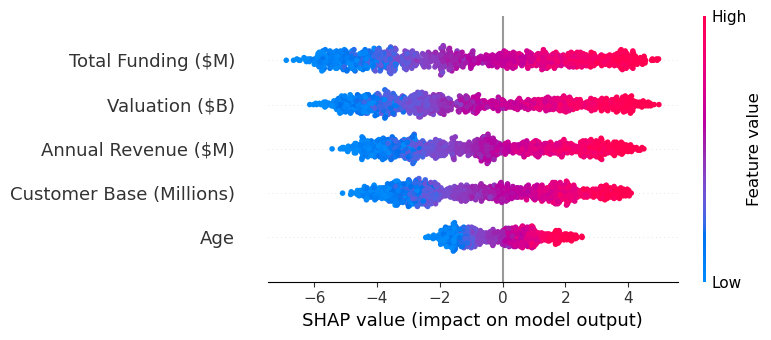

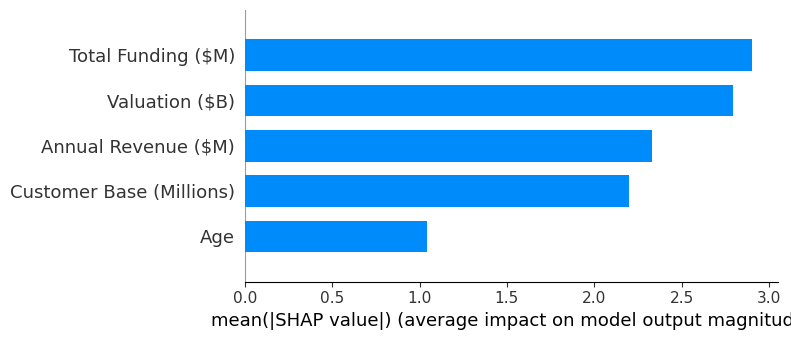

In [123]:
#4.6.4 SHAP EXPLAINABILITY FOR XGBOOST
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.initjs()

shap.summary_plot(shap_values, X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

sample_index = 0
shap.force_plot(explainer.expected_value, shap_values[sample_index], X_test.iloc[sample_index])